# Inferring a spatial code of communication in *C. elegans*

In [Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715), we previously searched for the
ligand-receptor pairs whose cell-cell interaction scores best explain the **physical distances**
between the cells of the whole animal

This analysis relies on a single-cell dataset whose cell types were identified in a digital 3D map of cell types. This notebook links predicted cell-cell interaction scores with the physical distances computed with this 3D map b using the function `cell2cell.analysis.optimize_lr_pairs`. Additionally, it compares the result against the pairs the
paper reports, and reproduces its functional enrichment of the selected list.

The data can be found in
[LewisLabUCSD/Celegans-cell2cell](https://github.com/LewisLabUCSD/Celegans-cell2cell), which can be read with pandas
directly from the URL.

For an introduction to the method on data where the answer is known in advance, see
[Identifying a spatial code of ligand-receptor pairs](./Genetic-Algorithm-LR-Selection).

**Requirements.** `pip install cell2cell[ga]`

In [1]:
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.spatial
import scipy.stats
from statsmodels.stats.multitest import multipletests

import cell2cell as c2c

%matplotlib inline

## 1. The data



In [2]:
BASE = ('https://raw.githubusercontent.com/LewisLabUCSD/'
        'Celegans-cell2cell/master/data/')

We start by loading the RNAseq data, in this case corresponds to gene expression matrix of the different cell types, aggregated from the single-cell dataset.

In [3]:
celegans_rnaseq = c2c.io.load_rnaseq(
    rnaseq_file=BASE + 'RNA-Seq/Celegans_RNASeqData_Cell.xlsx',
    gene_column='symbol', drop_nangenes=True, log_transformation=False,
    format='auto', verbose=False)

We continue by loading a curated list of ligand-receptor pairs of *C. elegans*.

In [4]:
celegans_lr = c2c.io.load_ppi(
    ppi_file=BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx',
    interaction_columns=('Ligand_symbol', 'Receptor_symbol'),
    rnaseq_genes=list(celegans_rnaseq.index), format='auto', verbose=False)

Finally, we load the 3D map that was pre-annotated with cell type labels matching the RNAseq data. With this we will know the spatial location of the different cell types.

In [5]:
physical_distances = pd.read_csv(
    BASE + 'Digital-3D-Map/Celegans_Physical_Distances_Min.csv', index_col=0)

The whole data used in this analysis consists of:

In [6]:
print('expression      :', celegans_rnaseq.shape, '(genes x cells)')
print('LR pairs        :', len(celegans_lr))
print('cells in the map:', physical_distances.shape[0])

expression      : (19391, 27) (genes x cells)
LR pairs        : 245
cells in the map: 22


The curated table carries more than the identifiers: a **WormBase gene id** for each partner and an
**LR function** for each pair.

In [8]:
curated = pd.read_excel(BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx')

# `remove_ppi_bidirectionality` can flip a pair, so look each one up both ways round
# and swap the annotation back when it was found reversed.
_curated = {(a, b): (ls, rs, fn) for a, b, ls, rs, fn in
            curated[['Ligand_symbol', 'Receptor_symbol', 
                     'Ligand_WB', 'Receptor_WB', 'LR Function']].values}

def annotate(frame, a='A', b='B'):
    """Adds ligand/receptor WB ids and the LR function to a frame of pairs."""
    records = []
    for x, y in frame[[a, b]].values:
        if (x, y) in _curated:
            ls, rs, fn = _curated[(x, y)]
        elif (y, x) in _curated:
            rs, ls, fn = _curated[(y, x)]        # found reversed: swap back
        else:
            ls = rs = fn = None
        records.append((ls, rs, fn))
    extra = pd.DataFrame(records, columns=['ligand', 'receptor', 'LR function'],
                         index=frame.index)
    return pd.concat([extra, frame.drop(columns=[a, b])], axis=1)

def pair_label(x, y):
    ls, rs, _ = _curated.get((x, y)) or tuple(reversed(_curated[(y, x)][:2])) + (None,)
    return '{}-{}'.format(ls, rs)

print('curated annotations for {} pairs'.format(len(curated)))
curated[['Ligand_WB', 'Receptor_WB', 'Ligand_symbol', 'Receptor_symbol', 'LR Function']].head()

curated annotations for 245 pairs


,Ligand_WB,Receptor_WB,Ligand_symbol,Receptor_symbol,LR Function
0,WBGene00000182,WBGene00004040,arf-1.2,pld-1,Cell adhesion
1,WBGene00000903,WBGene00004860,daf-7,sma-6,TGF-B signaling
2,WBGene00005647,WBGene00008779,srp-6,F14B4.1,Wnt signaling
3,WBGene00000074,WBGene00003930,adm-2,pat-3,Cell adhesion
4,WBGene00000074,WBGene00003929,adm-2,pat-2,Cell adhesion


## 2. Using a Genetic Algorithm to search LR pairs associated with physical distance

The study reported three ways of generating an aggregate CCI score between every pair of cells:

| Score | `communication_score` | `cci_score` | Notes |
|---|---|---|---|
| Bray-Curtis | `expression_thresholding` | `bray_curtis` | the main analysis |
| LR count | `expression_thresholding` | `count` | counts active pairs |
| ICELLNET | `expression_product` | `icellnet` | expression is `log2(x + 1)` transformed first |

As introducted by [Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715), we run the Bray-Curtis score, using the same published parameters: 200 individuals, 200 generations, a 10 TPM
threshold, and runs continuing until the objective improves by less than 2.5%.

In [12]:
celegans_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}

start = time.perf_counter()
celegans_results = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},   # 10 TPM
    analysis_setup=celegans_setup,
    population_size=200,
    generations=200,
    runs=None,                 # until the objective stops improving
    inc_percentage=0.025,
    random_state=888,
)
print('finished in {:.0f} s'.format(time.perf_counter() - start))

pd.DataFrame([{'run': k, 'objective': celegans_results[k]['obj_fn'],
               'LR pairs kept': celegans_results[k]['n_selected'],
               'LR fraction' : celegans_results[k]['n_selected'] / celegans_lr.shape[0]
              }
              for k in sorted(celegans_results) if k.startswith('run')])

finished in 25 s


,run,objective,LR pairs kept,LR fraction
0,run1,0.475020,97,0.395918
1,run2,0.592202,44,0.179592
2,run3,0.615437,27,0.110204
3,run4,0.615437,27,0.110204


In contrast to the [original implementation](https://github.com/LewisLabUCSD/Celegans-cell2cell/blob/master/code/genetic_algorithm.py), this new built-in function in ***cell2cell*** is much faster! Each of the ~40,000 objective evaluations per run (200 individuals x 200 generations) would otherwise have meant rebuilding the InteractionSpace each time, running for the order of mins/hours. Here, a new vectorized scorer is what brings the whole search down to seconds.

## 3. Comparing with the pairs published in the paper

The 37 pairs selected with the GA in the paper when using Bray-Curtis are in the same repository of the repo:

In [14]:
paper_pairs = pd.read_csv(BASE + 'PPI-Networks/Celegans-GA-BrayCurtis-Selected-LR-pairs.csv')

# `remove_ppi_bidirectionality` can flip a pair, so compare them as unordered
unordered = lambda a, b: frozenset((a, b))
paper_keys = {unordered(a, b) for a, b in
              paper_pairs[['Ligand_symbol', 'Receptor_symbol']].values}
our_keys = {unordered(a, b) for a, b in
            celegans_results['best_ppi_data'][['A', 'B']].values}

shared = our_keys & paper_keys
print('paper selection      : {} pairs'.format(len(paper_keys)))
print('our selection        : {} pairs'.format(len(our_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(our_keys - paper_keys)))
print('  of the paper\'s, we recovered {} ({:.0%})'
      .format(len(shared), len(shared) / len(paper_keys)))

paper selection      : 37 pairs
our selection        : 27 pairs
  also in the paper  : 18
  not in the paper   : 9
  of the paper's, we recovered 18 (49%)


### Integrating independent executions

Even though we identified a decent overlap with the published results, a single execution understates the agreement: a genetic
algorithm returns a *local* optimum, so different seeds land on different, largely overlapping sets.

The published analysis handled this by running the search many times independently, specifically 100 times, and asking which
pairs are selected **together**. `executions=N` performs multiple independent runs of the GA search and adds three
things to the result:

- `selection_frequency` — how often each pair was chosen;
- `cooccurrence` — the Jaccard index between the selection patterns of every two pairs, i.e. how
  often they are chosen alongside each other;
- `consensus_ppi_data` — the pairs of the co-occurrence cluster whose members are most consistently
  co-selected. **This is the output to use.**

For demonstration, here we run 30 independent GA searches with `executions=30`:

In [15]:
start = time.perf_counter()
consensus = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},
    analysis_setup=celegans_setup,
    population_size=200, generations=200, runs=None, inc_percentage=0.025,
    executions=30,             # thirty independent searches
    random_state=888,
)
print('30 executions in {:.0f} s'.format(time.perf_counter() - start))

annotate(consensus['selection_frequency']).head(12)

30 executions in 763 s


,ligand,receptor,LR function,frequency
206,WBGene00004890,WBGene00004047,Cell migration,1.000000
2,WBGene00019407,WBGene00011345,Cell migration,0.933333
243,WBGene00006951,WBGene00004208,Hedgehog signaling,0.900000
28,WBGene00000857,WBGene00003238,Wnt signaling,0.900000
51,WBGene00000936,WBGene00020649,TGF-B signaling,0.833333
166,WBGene00003111,WBGene00004048,Cell migration,0.833333
16,WBGene00000527,WBGene00001687,Cell adhesion,0.800000
22,WBGene00000674,WBGene00016104,Cell adhesion,0.766667
172,WBGene00003169,WBGene00003168,Mechanosensory mechanism,0.700000
159,WBGene00003029,WBGene00000478,Wnt signaling,0.666667


The co-occurrence matrix is what the consensus is built from. Clustering it separates a tight group
of pairs that keep being chosen together from a diffuse remainder.

In [16]:
sizes = {k: len(v) for k, v in consensus['consensus_clusters'].items()}
scores = {k: round(v, 3) for k, v in consensus['consensus_cluster_scores'].items()}
print('cluster sizes             :', sizes)
print('mean co-occurrence within :', scores)
print('\nconsensus selection: {} pairs'.format(len(consensus['consensus_ppi_data'])))

cluster sizes             : {np.int32(1): 21, np.int32(2): 83}
mean co-occurrence within : {np.int32(1): 0.529, np.int32(2): 0.076}

consensus selection: 21 pairs


In [17]:
consensus_keys = {unordered(a, b) for a, b in consensus['consensus_ppi_data'][['A', 'B']].values}
shared = consensus_keys & paper_keys
print('consensus selection  : {} pairs'.format(len(consensus_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(consensus_keys - paper_keys)))

annotate(consensus['consensus_ppi_data']).assign(
    in_paper=[unordered(a, b) in paper_keys
              for a, b in consensus['consensus_ppi_data'][['A', 'B']].values]) \
    .sort_values(['in_paper', 'ligand'], ascending=[False, True])

consensus selection  : 21 pairs
  also in the paper  : 21
  not in the paper   : 0


,ligand,receptor,LR function,score,in_paper
1,WBGene00000527,WBGene00001687,Cell adhesion,1.0,True
2,WBGene00000674,WBGene00016104,Cell adhesion,1.0,True
3,WBGene00000857,WBGene00003238,Wnt signaling,1.0,True
4,WBGene00000936,WBGene00020649,TGF-B signaling,1.0,True
5,WBGene00001700,WBGene00004208,Hedgehog signaling,1.0,True
6,WBGene00002280,WBGene00003930,Cell adhesion,1.0,True
7,WBGene00002881,WBGene00006894,Canonical RTK-Ras-ERK signaling,1.0,True
8,WBGene00003029,WBGene00000289,Wnt signaling,1.0,True
9,WBGene00003029,WBGene00000478,Wnt signaling,1.0,True
10,WBGene00003111,WBGene00004048,Cell migration,1.0,True


In the original algorithm, a consensus list is built by clustering the co-occurence matrix of every pair of LR pairs across all executions of the GA. The two criteria for *which* cluster to keep here is set by `cluster_selection='cooccurrence'` (the default), which ranks by mean co-occurrence among a cluster's own members, which is the property the analysis is actually after.

> **How many executions?** The clustering needs enough of them. Two pairs selected once, in the same
> execution, have a co-occurrence of 1.0 without that meaning anything, and with too few executions a
> cluster of such pairs outscores the reproducible one — with 10 executions this analysis returns 17
> pairs of which only 6 are the paper's, against 29 of 31 with 30. Use around 30 or more (the
> reference analysis used about a hundred), or set `min_frequency` to drop the rarely-chosen pairs.
> The frequency route below is the more forgiving of the two.

#### The simpler alternative: selection frequency

Rather than asking which pairs are chosen *together*, one can just keep those chosen *often*. The
reference notebook computed this too, using the 90th percentile of the frequency distribution. It is
easier to reason about, but it cannot separate two groups of pairs that are each self-consistent yet
rarely co-selected.

In [18]:
frequency = consensus['selection_frequency']['frequency'].values

for percentile in (80, 85, 90, 95):
    mask, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=percentile)
    kept = consensus['selection_frequency'].loc[mask]
    keys = {unordered(a, b) for a, b in kept[['A', 'B']].values}
    print('{}th percentile (frequency > {:.2f}): {:>2} pairs | {:>2} in the paper, {:>2} not'
          .format(percentile, threshold, len(keys), len(keys & paper_keys),
                  len(keys - paper_keys)))

80th percentile (frequency > 0.17): 42 pairs | 34 in the paper,  8 not
85th percentile (frequency > 0.23): 36 pairs | 31 in the paper,  5 not
90th percentile (frequency > 0.40): 24 pairs | 24 in the paper,  0 not
95th percentile (frequency > 0.63): 12 pairs | 12 in the paper,  0 not


Both routes converge on the same set of pairs — the ones the paper reports. Which to prefer depends
on the question: the co-occurrence clustering keeps groups of pairs that act together, while the
frequency threshold is a plain ranking of individual pairs.

The same steps are available on their own, for integrating results computed elsewhere:
`c2c.analysis.lr_selection_frequency`, `lr_cooccurrence`, `consensus_from_cooccurrence` and
`consensus_from_frequency`.

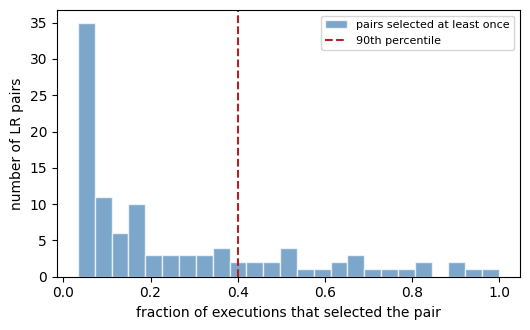

In [19]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.hist(frequency[frequency > 0], bins=25, color='steelblue', alpha=0.7,
        edgecolor='w', label='pairs selected at least once')
_, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=90)
ax.axvline(threshold, color='firebrick', ls='--', label='90th percentile')
ax.set_xlabel('fraction of executions that selected the pair')
ax.set_ylabel('number of LR pairs'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Which functions are the selected pairs enriched for?

The curated ligand-receptor table annotates every pair with an **LR function** — Wnt signalling,
cell adhesion, Hedgehog signalling, and so on. Asking which of those the search favours turns a list
of gene pairs into a statement about biology.

The paper's test, reproduced here:

1. every execution contributes its selected list;
2. for each execution, the **fraction** of its list falling in each function;
3. the background is the fraction of each function in the **full** pair list;
4. a Wilcoxon signed-rank test compares the distribution of per-execution fractions against that
   background, one-sided in each direction;
5. Benjamini-Hochberg across functions, reporting the smaller of the two adjusted values.

The test operates on the spread across executions, so **its resolution is bounded by how many there
are**: with *n* executions the smallest achievable one-sided p-value is `2**-n`. With 8 everything
floors around 0.004 and looks marginal; the 30 used here floor near `1e-9`, and the paper used about
a hundred.

In [20]:
# `functions` reuses the annotation built in section 1. The pool is what the masks
# are indexed against -- `selection_frequency` is sorted, so pairing that with the
# masks positionally would misalign them.
pool = consensus['pool']
functions = annotate(pool)['LR function']
print('pairs with a curated function: {} of {}'.format(functions.notna().sum(), len(functions)))

masks = np.asarray(consensus['selection_masks'])
counts = pd.DataFrame(masks.T, index=functions.values).groupby(level=0).sum()
fractions = counts / counts.sum()                      # function x execution
background = functions.value_counts(normalize=True)    # the full list
print('{} functions, {} executions'.format(*fractions.shape))

pairs with a curated function: 245 of 245
20 functions, 30 executions


In [21]:
rows = []
for function, row in fractions.iterrows():
    difference = row.values - background[function]
    if np.any(difference != 0):
        greater = scipy.stats.wilcoxon(difference, alternative='greater')[1]
        less = scipy.stats.wilcoxon(difference, alternative='less')[1]
    else:
        greater = less = 1.0
    rows.append({'LR Function': function,
                 'n_pairs': int((functions == function).sum()),
                 'greater_p': greater, 'less_p': less,
                 'fold_change': row.median() / background[function]})

enrichment = pd.DataFrame(rows).set_index('LR Function')
for side in ('greater', 'less'):
    enrichment[side + '_q'] = multipletests(enrichment[side + '_p'].values,
                                            alpha=0.01, method='fdr_bh')[1]
enrichment['adj_p'] = enrichment[['greater_q', 'less_q']].min(axis=1)
enrichment['direction'] = np.where(enrichment['fold_change'] > 1, 'enriched', 'depleted')
enrichment = enrichment.sort_values('fold_change', ascending=False)
enrichment[['n_pairs', 'fold_change', 'adj_p', 'direction']].round(4)

,n_pairs,fold_change,adj_p,direction
LR Function,,,,
Hedgehog signaling,6,3.0829,0.0000,enriched
Cell migration,27,1.8148,0.0000,enriched
Mechanosensory mechanism,6,1.7014,0.0003,enriched
Canonical RTK-Ras-ERK signaling,8,1.2014,0.6029,enriched
Wnt signaling,45,1.1836,0.0329,enriched
TGF-B signaling,19,1.1213,0.1044,enriched
Notch signaling,24,0.8628,0.1269,depleted
Neuronal communication,4,0.8507,0.0835,depleted
Cell adhesion,46,0.7478,0.0000,depleted


The figure the paper reports: one box per function over the per-execution fold changes, on a
`log10(FC + 1)` scale so that a fold change of 1 — no enrichment — sits at `log10(2) ≈ 0.30`.

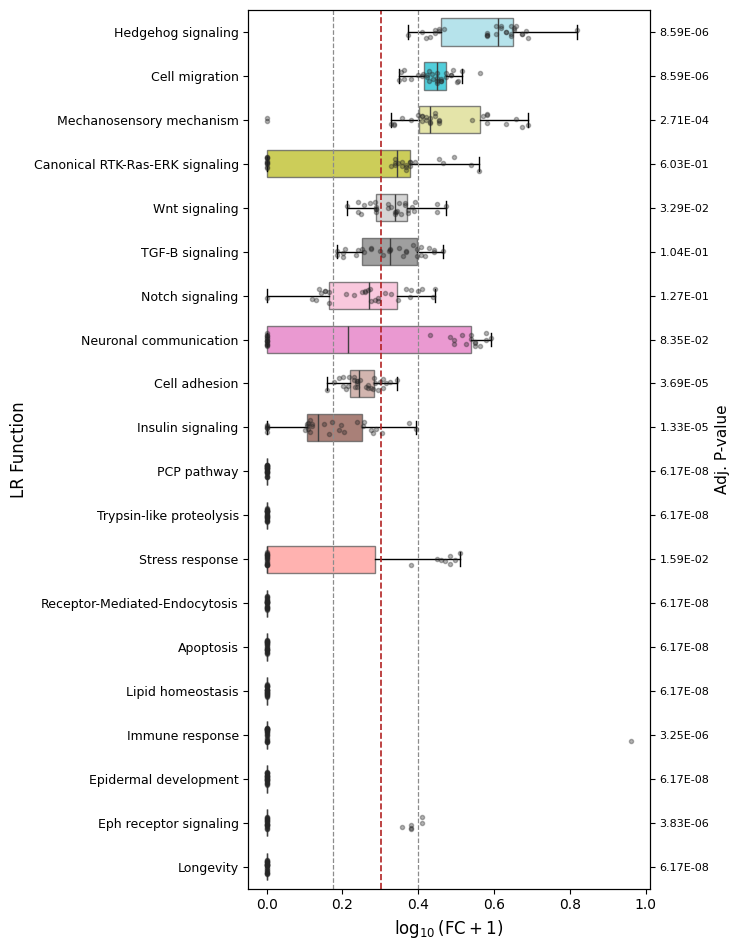

In [22]:
fold_changes = fractions.div(background, axis=0)
plot_order = enrichment.index[::-1]
values = [np.log10(fold_changes.loc[f].values + 1) for f in plot_order]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(plot_order) + 1.2))
colours = plt.get_cmap('tab20')(np.linspace(0, 1, len(plot_order)))
bp = ax.boxplot(values, vert=False, patch_artist=True, widths=0.62,
                medianprops=dict(color='0.25'), flierprops=dict(marker=''))
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour); patch.set_alpha(0.75); patch.set_edgecolor('0.35')

rng_jitter = np.random.default_rng(0)
for i, v in enumerate(values, start=1):
    ax.scatter(v, i + rng_jitter.uniform(-0.16, 0.16, len(v)), s=9,
               color='0.15', alpha=0.35, zorder=3)

ax.axvline(np.log10(2), color='firebrick', ls='--', lw=1.2)          # fold change of 1
for fc in (0.5, 1.5):
    ax.axvline(np.log10(fc + 1), color='0.55', ls='--', lw=0.9)
ax.set_yticks(range(1, len(plot_order) + 1)); ax.set_yticklabels(plot_order, fontsize=9)
ax.set_xlabel('$\\log_{10}(\\mathrm{FC}+1)$', fontsize=12)
ax.set_ylabel('LR Function', fontsize=12)

right = ax.twinx()
right.set_ylim(ax.get_ylim()); right.set_yticks(range(1, len(plot_order) + 1))
right.set_yticklabels(['{:.2E}'.format(enrichment.loc[f, 'adj_p']) for f in plot_order], fontsize=8)
right.set_ylabel('Adj. P-value', fontsize=11)
plt.tight_layout(); plt.show()

The red line is no enrichment; the grey lines mark fold changes of 0.5 and 1.5. Functions whose
boxes sit entirely at 0 were never chosen by any execution — strongly *depleted*, and the Wilcoxon
reports them as such rather than as absent evidence.

Two things to keep in mind when reading this:

- **It is conditioned on the curated annotation.** A function with one or two pairs in the whole
  list cannot show a stable fold change, and its p-value reflects consistency across executions
  rather than strength of evidence about biology.
- **Depletion is a real result here**, not a failure to detect. A function that the search reliably
  drops is one whose pairs do not help explain physical distance — which is informative given that
  the background is the curated list someone assembled as plausible.

## Notes

- **`pygad` is not `pyevolve`**, the seeds differ, and the published set is one run of many, so the
  numbers will not match exactly. The reproducible core is what should agree, and does.
- **No multiprocessing.** The original distributed independent runs across cores; the vectorized
  objective makes one run fast enough that it is not needed.
- **`selection_masks` is indexed against `results['pool']`**, not against `selection_frequency`,
  which is sorted by frequency for reading. Pairing the sorted frame with the masks positionally is
  a silent misalignment.